## Logistic Regression Implementation

In [61]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
%matplotlib inline

In [62]:
from sklearn.datasets import make_classification

In [63]:
X,y=make_classification(n_samples=1000,n_features=10,n_classes=2,random_state=15)

In [64]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=15)

In [65]:
from sklearn.linear_model import LogisticRegression
logistic=LogisticRegression()

In [66]:
logistic.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [67]:
y_pred=logistic.predict(X_test)
y_pred

array([0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1])

In [68]:
## Performance Metrics
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
score=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)
print(f"Accuracy Score : {score}\n")
print(f"Confusion Matrix : \n{cm}\n")
print(f"Classification Report : \n{cr}")

Accuracy Score : 0.92

Confusion Matrix : 
[[134  11]
 [ 13 142]]

Classification Report : 
              precision    recall  f1-score   support

           0       0.91      0.92      0.92       145
           1       0.93      0.92      0.92       155

    accuracy                           0.92       300
   macro avg       0.92      0.92      0.92       300
weighted avg       0.92      0.92      0.92       300



## Hperparameter tuning and Cross Validation

In [69]:
model=LogisticRegression()
penalty=['l1','l2','elasticnet']
c_values=[100,10,0.1,0,1]
solver=['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']

In [70]:
model=LogisticRegression()
C_values = [100.0, 10.0, 1.0, 0.1, 0.01, 0.001]

# Define the Grid Search parameter space as a list of dictionaries
param_grid = [
    # Solvers that only support L2 (and None, but L2 is common)
    {
        'solver': ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag'],
        'penalty': ['l2'],
        'C': C_values
    },
    # Solver that supports L1 and L2 (best for small datasets)
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': C_values
    },
    # Solver that supports L1, L2, and Elasticnet (the most versatile)
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2'],
        'C': C_values
    },
    # Elasticnet combination (requires l1_ratio and saga)
    {
        'solver': ['saga'],
        'penalty': ['elasticnet'],
        'l1_ratio': [0.1, 0.5, 0.9], # Add the required l1_ratio parameter
        'C': C_values
    }
]

### Grid SearchCV

In [71]:
from sklearn.model_selection import GridSearchCV,StratifiedKFold
cv=StratifiedKFold()
grid=GridSearchCV(estimator=model,param_grid=param_grid,scoring='accuracy',cv=cv,n_jobs=-1)

In [72]:
grid

,estimator,LogisticRegression()
,param_grid,"[{'C': [100.0, 10.0, ...], 'penalty': ['l2'], 'solver': ['lbfgs', 'newton-cg', ...]}, {'C': [100.0, 10.0, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}, ...]"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [73]:
grid.fit(X_train,y_train)

,estimator,LogisticRegression()
,param_grid,"[{'C': [100.0, 10.0, ...], 'penalty': ['l2'], 'solver': ['lbfgs', 'newton-cg', ...]}, {'C': [100.0, 10.0, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}, ...]"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'elasticnet'


In [74]:
grid.best_params_

{'C': 0.1, 'l1_ratio': 0.5, 'penalty': 'elasticnet', 'solver': 'saga'}

In [75]:
grid.best_score_

np.float64(0.9242857142857142)

In [76]:
y_pred=grid.predict(X_test)

In [77]:
score=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)
print(f"Accuracy Score : {score}\n")
print(f"Confusion Matrix : \n{cm}\n")
print(f"Classification Report : \n{cr}")

Accuracy Score : 0.93

Confusion Matrix : 
[[138   7]
 [ 14 141]]

Classification Report : 
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       145
           1       0.95      0.91      0.93       155

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300



## Randomized SearchCV

In [80]:
model=LogisticRegression()
C_values = [100.0, 10.0, 1.0, 0.1, 0.01, 0.001]

# Define the Grid Search parameter space as a list of dictionaries
param_grid = [
    # Solvers that only support L2 (and None, but L2 is common)
    {
        'solver': ['lbfgs', 'newton-cg', 'newton-cholesky', 'sag'],
        'penalty': ['l2'],
        'C': C_values
    },
    # Solver that supports L1 and L2 (best for small datasets)
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': C_values
    },
    # Solver that supports L1, L2, and Elasticnet (the most versatile)
    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2'],
        'C': C_values
    },
    # Elasticnet combination (requires l1_ratio and saga)
    {
        'solver': ['saga'],
        'penalty': ['elasticnet'],
        'l1_ratio': [0.1, 0.5, 0.9], # Add the required l1_ratio parameter
        'C': C_values
    }
]

In [89]:
from sklearn.model_selection import RandomizedSearchCV
randomcv=RandomizedSearchCV(estimator=model,param_distributions=param_grid,scoring='accuracy',cv=cv,n_jobs=-1)

In [92]:
randomcv.fit(X_train,y_train)

,estimator,LogisticRegression()
,param_distributions,"[{'C': [100.0, 10.0, ...], 'penalty': ['l2'], 'solver': ['lbfgs', 'newton-cg', ...]}, {'C': [100.0, 10.0, ...], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}, ...]"
,n_iter,10
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [93]:
randomcv.best_score_

np.float64(0.9228571428571428)

In [94]:
randomcv.best_params_

{'solver': 'saga', 'penalty': 'elasticnet', 'l1_ratio': 0.1, 'C': 0.01}

In [98]:
y_pred=randomcv.predict(X_test)

In [99]:
score=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)
print(f"Accuracy Score : {score}\n")
print(f"Confusion Matrix : \n{cm}\n")
print(f"Classification Report : \n{cr}")

Accuracy Score : 0.93

Confusion Matrix : 
[[140   5]
 [ 16 139]]

Classification Report : 
              precision    recall  f1-score   support

           0       0.90      0.97      0.93       145
           1       0.97      0.90      0.93       155

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300



## Logistic Regression for Multi-Class Classification

In [124]:
X,y=make_classification(n_samples=1000,n_features=10,n_informative=3,n_classes=3,random_state=15)

In [125]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=15)

In [126]:
logistic=LogisticRegression(multi_class='ovr')
logistic.fit(X_train,y_train)
y_pred=logistic.predict(X_test)

c:\Users\Inderjeet\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [127]:
score=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)
print(f"Accuracy Score : {score}\n")
print(f"Confusion Matrix : \n{cm}\n")
print(f"Classification Report : \n{cr}")

Accuracy Score : 0.7833333333333333

Confusion Matrix : 
[[83 16  6]
 [ 2 69 26]
 [ 6  9 83]]

Classification Report : 
              precision    recall  f1-score   support

           0       0.91      0.79      0.85       105
           1       0.73      0.71      0.72        97
           2       0.72      0.85      0.78        98

    accuracy                           0.78       300
   macro avg       0.79      0.78      0.78       300
weighted avg       0.79      0.78      0.78       300



## Logistic Regression for Imbalanced Datasets

In [128]:
from collections import Counter
from sklearn.datasets import make_classification

In [129]:
X,y=make_classification(n_samples=10000,n_features=2,n_clusters_per_class=1,n_redundant=0,weights=[0.99],random_state=10)

In [130]:
X

array([[ 1.87991016, -1.4850347 ],
       [ 0.37708311, -2.23858488],
       [ 1.35431163, -2.66463822],
       ...,
       [ 0.99509904, -0.54192355],
       [ 1.75859359, -1.54961188],
       [ 0.79770543, -1.99467372]], shape=(10000, 2))

In [131]:
Counter(y)

Counter({np.int64(0): 9846, np.int64(1): 154})

In [134]:
import seaborn as sns
import pandas as pd


# Convert X to a DataFrame and name the columns
df_X = pd.DataFrame(X).iloc[:, :2] # Use only the first two features for a 2D plot
df_X.columns = ['Feature_1', 'Feature_2']

# Add the target variable 'y' to the DataFrame
df_X['Target'] = y

# Rename the combined DataFrame
plot_data = df_X

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

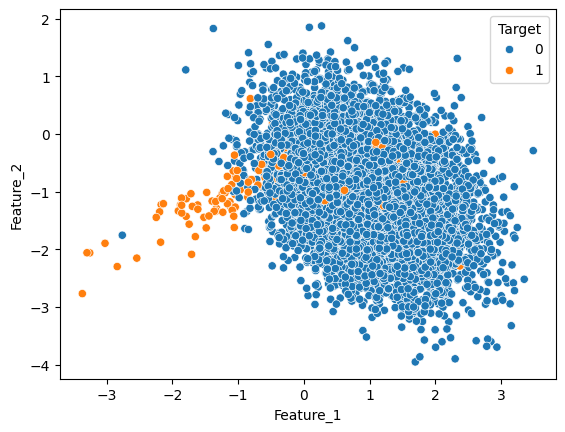

In [135]:
sns.scatterplot(
    data=plot_data, 
    x='Feature_1', 
    y='Feature_2', 
    hue='Target'
)

In [136]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [138]:
## Hyperparameter Tuning
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

# Lines 4-7: Define the hyperparameter lists
penalty = ['l1', 'l2', 'elasticnet']
c_values = [100, 10, 1.0, 0.1, 0.01]
solver = ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']

class_weight = [{0:w, 1:y} for w in [1, 10, 50, 100] for y in [1, 10, 50, 100]]

params = dict(
    penalty=penalty, 
    C=c_values, 
    solver=solver, 
    class_weight=class_weight
)

In [140]:
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [139]:
params

{'penalty': ['l1', 'l2', 'elasticnet'],
 'C': [100, 10, 1.0, 0.1, 0.01],
 'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
 'class_weight': [{0: 1, 1: 1},
  {0: 1, 1: 10},
  {0: 1, 1: 50},
  {0: 1, 1: 100},
  {0: 10, 1: 1},
  {0: 10, 1: 10},
  {0: 10, 1: 50},
  {0: 10, 1: 100},
  {0: 50, 1: 1},
  {0: 50, 1: 10},
  {0: 50, 1: 50},
  {0: 50, 1: 100},
  {0: 100, 1: 1},
  {0: 100, 1: 10},
  {0: 100, 1: 50},
  {0: 100, 1: 100}]}

In [141]:
from sklearn.model_selection import GridSearchCV,StratifiedKFold
cv=StratifiedKFold()
grid=GridSearchCV(estimator=model,param_grid=params,scoring='accuracy',cv=cv,n_jobs=-1)

In [143]:
grid.fit(X_train,y_train)

c:\Users\Inderjeet\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
3200 fits failed out of a total of 6000.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
400 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Inderjeet\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Inderjeet\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\U

,estimator,LogisticRegression()
,param_grid,"{'C': [100, 10, ...], 'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10}, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo...shuffle=False)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l1'


In [144]:
grid.best_params_

{'C': 100,
 'class_weight': {0: 50, 1: 100},
 'penalty': 'l1',
 'solver': 'liblinear'}

In [145]:
grid.best_score_

np.float64(0.9882666666666667)

In [146]:
y_pred=grid.predict(X_test)

In [147]:
score=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cr=classification_report(y_test,y_pred)
print(f"Accuracy Score : {score}\n")
print(f"Confusion Matrix : \n{cm}\n")
print(f"Classification Report : \n{cr}")

Accuracy Score : 0.9896

Confusion Matrix : 
[[2465    0]
 [  26    9]]

Classification Report : 
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2465
           1       1.00      0.26      0.41        35

    accuracy                           0.99      2500
   macro avg       0.99      0.63      0.70      2500
weighted avg       0.99      0.99      0.99      2500



## Logistic Regression with ROC curve And ROC AUC score

In [3]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve,roc_auc_score
from matplotlib import pyplot as plt

In [4]:
# Generate a binary classification dataset
X,y=make_classification(n_samples=1000,n_classes=2,random_state=1)

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [7]:
# Creating a dummy mocdel that predicts default 0 as output
dummy_model_probs=[0 for _ in range(len(y_test))] 
dummy_model_probs

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0]

In [8]:
## Logistic Regression Model
model=LogisticRegression()
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [10]:
## Prediction based on probabilities
model_prob=model.predict_proba(X_test)

In [11]:
model_prob=model_prob[:,1]  # Probabilities for the positive class

In [12]:
model_prob

array([9.99041225e-01, 9.68866009e-02, 4.89372036e-01, 8.10046974e-01,
       1.12426807e-01, 4.39872005e-01, 8.29460814e-01, 7.13822440e-01,
       8.87707883e-01, 8.67973855e-01, 5.43854787e-04, 8.31200361e-01,
       1.91030219e-01, 5.39053079e-01, 7.28060254e-01, 8.23507048e-01,
       9.38587042e-01, 6.38367304e-01, 1.10159811e-01, 2.41034347e-01,
       1.15857322e-02, 4.90154702e-01, 8.88085107e-01, 9.97948102e-01,
       1.36945498e-01, 1.32643249e-02, 6.45087847e-01, 9.69507009e-01,
       3.99070556e-02, 2.38152731e-02, 3.69213417e-01, 3.40314906e-02,
       2.29858043e-01, 9.57101721e-01, 5.44958479e-01, 6.56791269e-01,
       1.52123558e-02, 2.93410161e-02, 7.80393330e-01, 2.99088014e-02,
       9.28398422e-01, 8.43395917e-01, 1.60117892e-02, 5.78395703e-04,
       6.61496895e-02, 6.69762422e-02, 9.97948178e-01, 6.55755704e-01,
       8.94036983e-01, 6.07000680e-02, 2.10340754e-02, 3.23954283e-02,
       1.03560315e-01, 5.44021349e-02, 5.64730236e-01, 9.87033757e-01,
      

In [13]:
## Scores
dummy_auc=roc_auc_score(y_test,dummy_model_probs)
model_auc=roc_auc_score(y_test,model_prob)  
print(f"Dummy Model AUC: {dummy_auc}")
print(f"Logistic Regression Model AUC: {model_auc}")

Dummy Model AUC: 0.5
Logistic Regression Model AUC: 0.9108885464817668


# Classification Metrics: FPR and TPR


## 1. False Positive Rate (FPR)

The False Positive Rate (FPR) is the proportion of **negative** cases that were **incorrectly** classified as positive (a "Type I Error").

### Formula 
$$
FPR = \frac{FP}{N} = \frac{FP}{FP + TN}
$$

### Variable Definitions
* **$FP$**: **F**alse **P**ositives (Negative cases incorrectly predicted as Positive).
* **$TN$**: **T**rue **N**egatives (Negative cases correctly predicted as Negative).
* **$N$**: **Total number of negatives** ($FP + TN$).

---

## 2. True Positive Rate (TPR)

The True Positive Rate (TPR), also known as **Sensitivity**, **Recall**, or **Hit Rate**, is the proportion of **positive** cases that were **correctly** classified as positive.

### Formula 
$$
TPR = \frac{TP}{P} = \frac{TP}{TP + FN} = 1 - FNR
$$

### Variable Definitions
* **$TP$**: **T**rue **P**ositives (Positive cases correctly predicted as Positive).
* **$FN$**: **F**alse **N**egatives (Positive cases incorrectly predicted as Negative).
* **$P$**: **Total number of positives** ($TP + FN$).
* **$FNR$**: **F**alse **N**egative **R**ate.

---

In [18]:
## calculate ROC curve
dummy_fpr, dummy_tpr, _ = roc_curve(y_test,dummy_model_probs)
model_fpr, model_tpr, thresholds = roc_curve(y_test,model_prob)

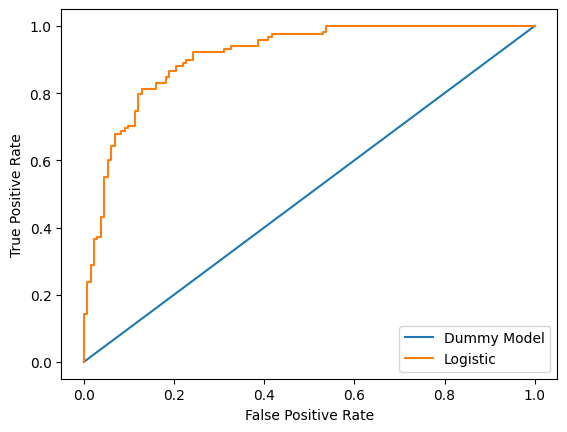

In [19]:
## Plotting ROC curve
plt.plot(dummy_fpr, dummy_tpr, label='Dummy Model')
plt.plot(model_fpr, model_tpr, label='Logistic')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

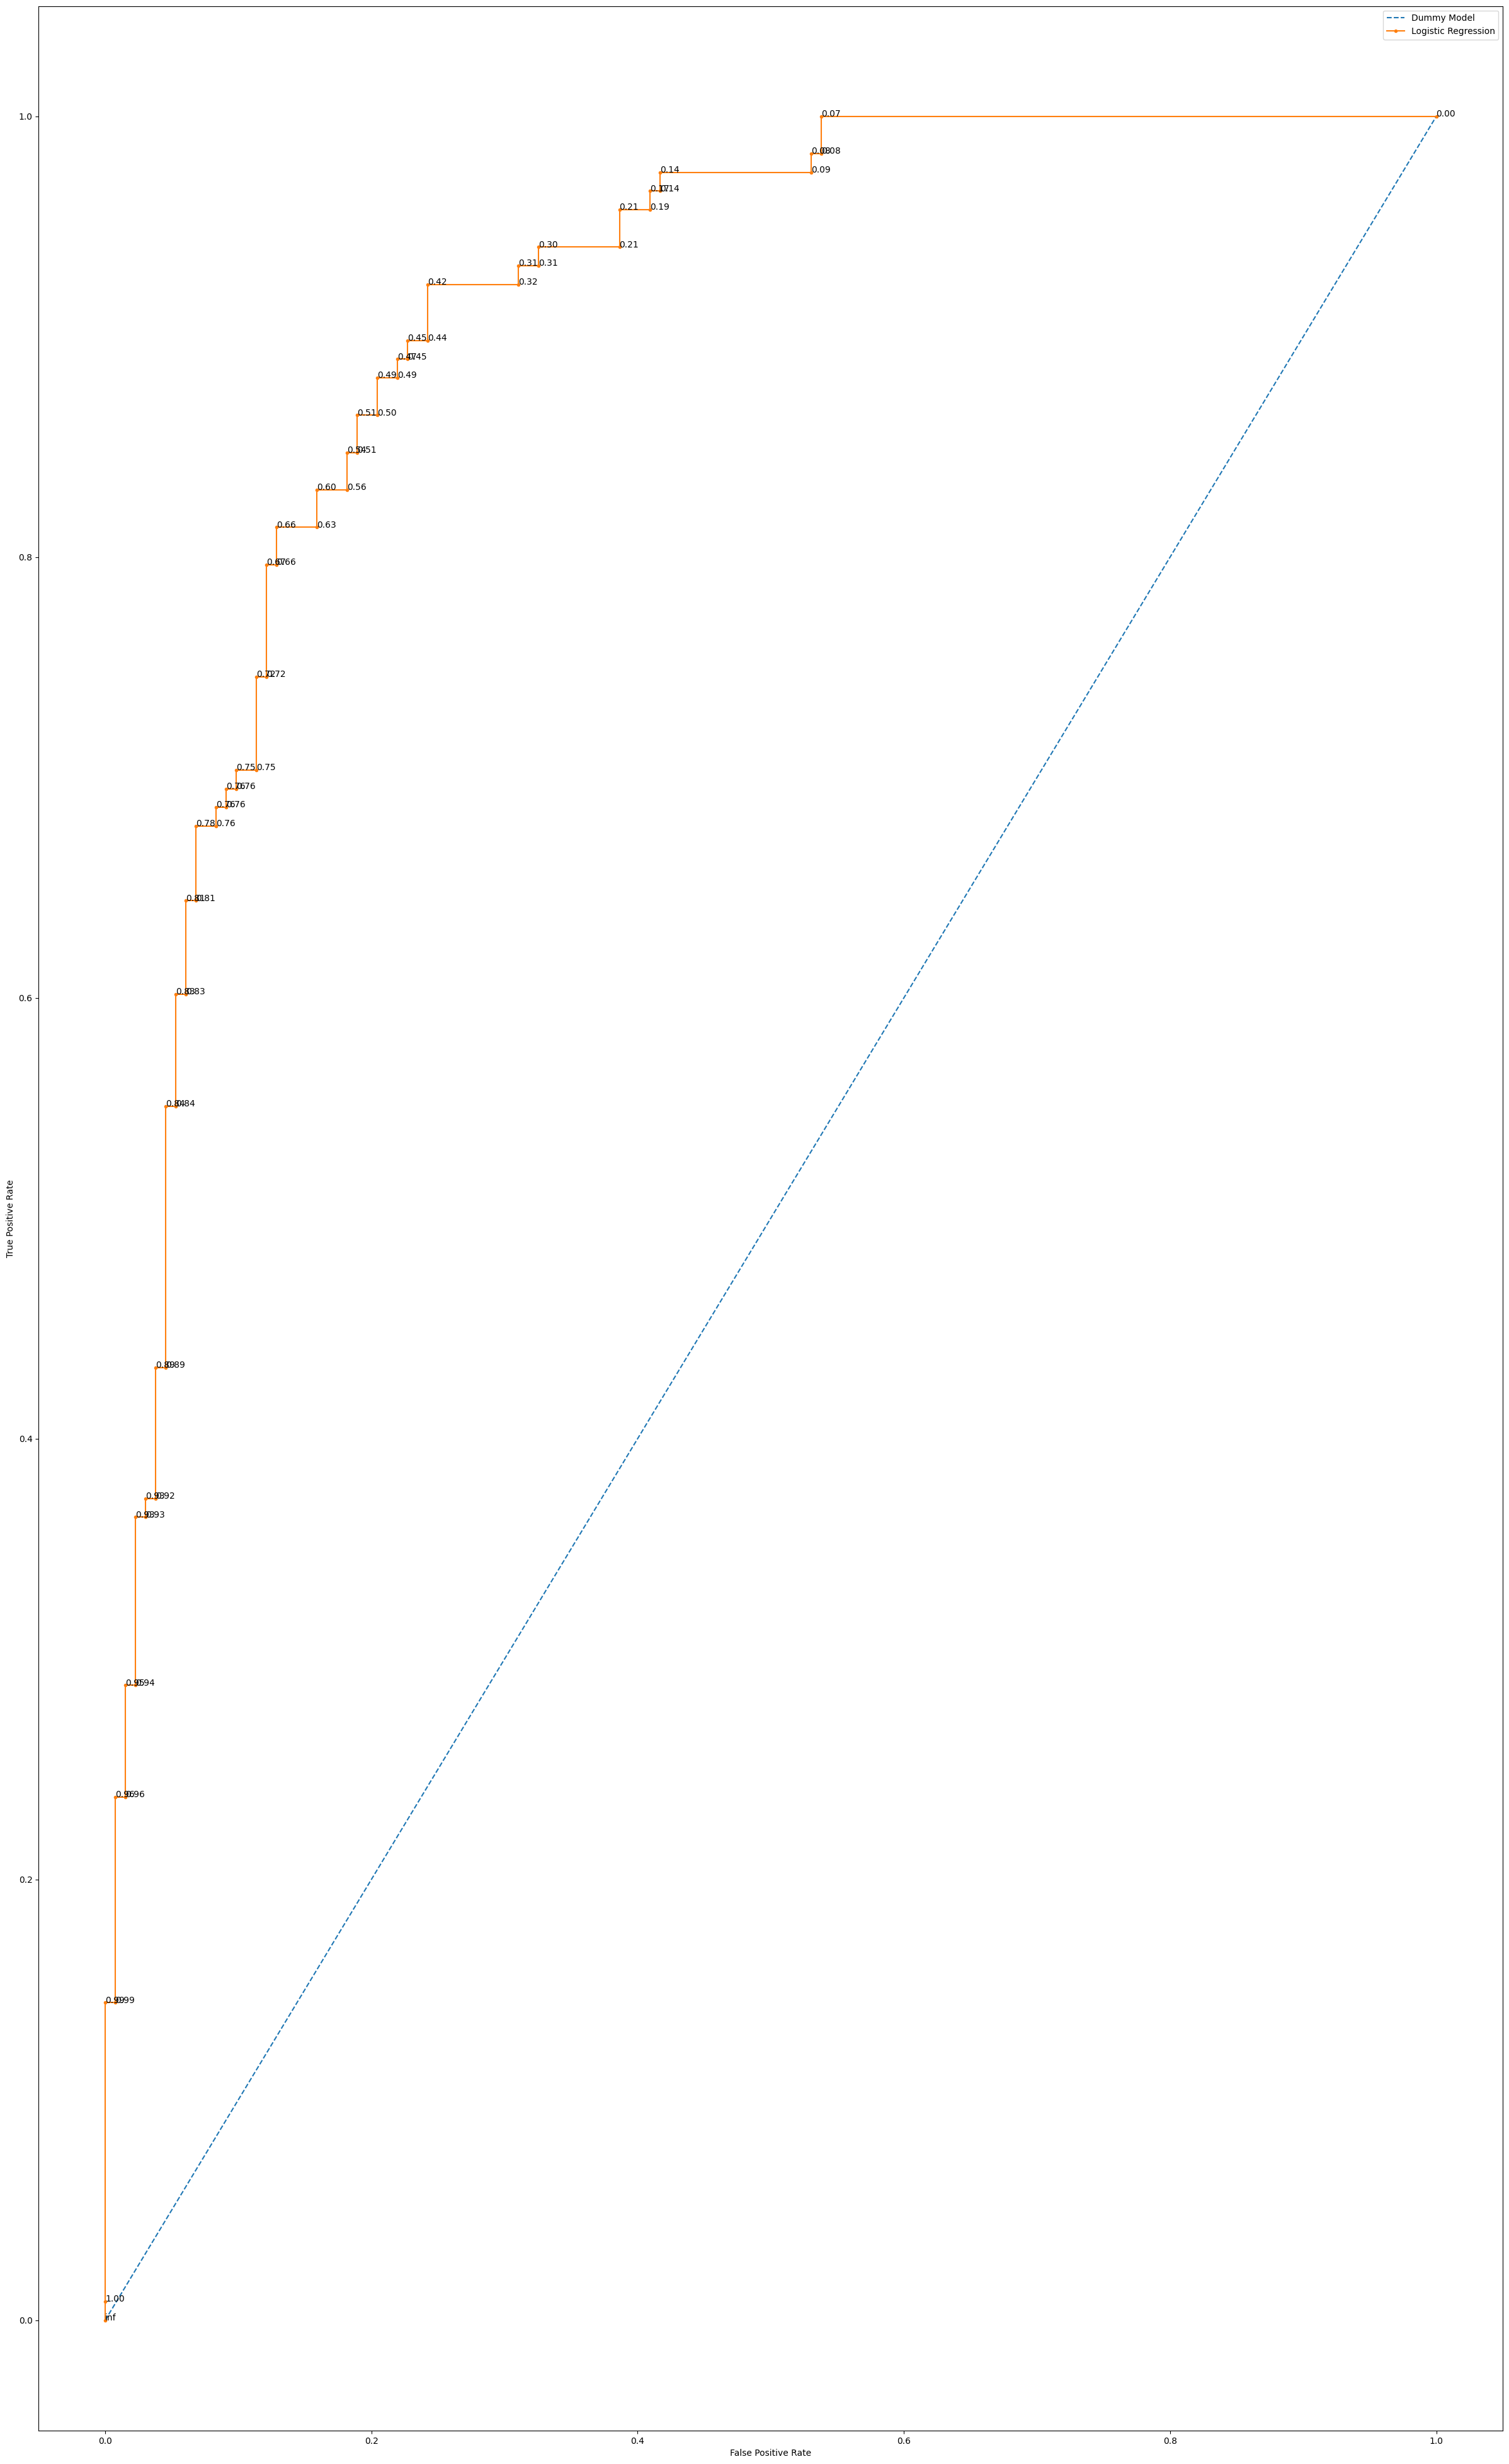

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(30,50))
plt.plot(dummy_fpr, dummy_tpr, linestyle='--', label='Dummy Model')
plt.plot(model_fpr, model_tpr, marker='.', label='Logistic Regression')

for fpr, tpr, thresh in zip(model_fpr, model_tpr, thresholds):
    plt.annotate(f'{thresh:.2f}', (fpr, tpr))

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()